<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [1]:
!pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-gpu openpyxl datasets langchain-community ragatouille umap-learn

ERROR: Could not find a version that satisfies the requirement faiss-gpu (from versions: none)
ERROR: No matching distribution found for faiss-gpu


In [1]:
!pip install -q gdown torch transformers accelerate bitsandbytes langchain sentence-transformers faiss-cpu openpyxl datasets langchain-community ragatouille umap-learn

In [2]:
!pip uninstall langchain langchain-community -y
!pip install langchain==0.1.0 langchain-community==0.0.10
from langchain.schema import Document as LangchainDocument

Found existing installation: langchain 0.1.0
Uninstalling langchain-0.1.0:
  Successfully uninstalled langchain-0.1.0
Found existing installation: langchain-community 0.0.10
Uninstalling langchain-community-0.0.10:
  Successfully uninstalled langchain-community-0.0.10
  Using cached langchain-0.1.0-py3-none-any.whl.metadata (13 kB)
  Using cached langchain_community-0.0.10-py3-none-any.whl.metadata (7.3 kB)
Using cached langchain-0.1.0-py3-none-any.whl (797 kB)
Using cached langchain_community-0.0.10-py3-none-any.whl (1.5 MB)


In [3]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain.schema import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from ragatouille import RAGPretrainedModel
from langchain.text_splitter import RecursiveCharacterTextSplitter, CharacterTextSplitter, TokenTextSplitter
#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки

# pd.set_option("display.max_colwidth", None)

/tmp/ipykernel_22652/831194255.py:17: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel


## Загрузка данных (4 балла)

In [4]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=59417730-de1e-4dbc-ae5b-46b1bcfe5947
To: /content/file.csv
100%|██████████| 672M/672M [00:07<00:00, 85.3MB/s]


In [5]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [6]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [7]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

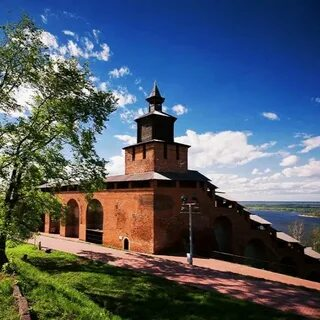

In [8]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

tfidf = TfidfVectorizer(max_features=50, stop_words=['the', 'a', 'an', 'is', 'are', 'there'])
tfidf_matrix = tfidf.fit_transform(data['en_txt'].fillna(''))

avg_tfidf = np.array(tfidf_matrix.mean(axis=1)).flatten()
data['tfidf_score'] = avg_tfidf

threshold = np.percentile(avg_tfidf, 95)
data['is_outlier'] = data['tfidf_score'] > threshold

clean_data = data[~data['is_outlier']].copy()

stratified_sample = clean_data.groupby(['City', 'Name'], group_keys=False).apply(
    lambda x: x.sample(min(len(x), 1), random_state=42)
).reset_index(drop=True).sample(n=min(100, len(clean_data)), random_state=42)

stratified_sample['best_description'] = stratified_sample.groupby('Name')['en_txt'].transform(
    lambda x: x.loc[x.str.len().idxmax()] if len(x) > 0 else x.iloc[0]
)

print(f"Чистых записей: {len(clean_data)}")
print(f"Удалено выбросов: {data['is_outlier'].sum()}")
print(f"Итоговый размер sample: {len(stratified_sample)}")
stratified_sample[['Name', 'City', 'best_description']].head()

Чистых записей: 13903
Удалено выбросов: 731
Итоговый размер sample: 100


/tmp/ipykernel_22652/2838732700.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = clean_data.groupby(['City', 'Name'], group_keys=False).apply(


,Name,City,best_description
9,Бывшая водонапорная башня,Владимир,there is a large red brick building with a tow...
42,Исторический музей,Владимир,arafed view of a city with a church and a river
33,Дмитриевский собор,Владимир,arafed church with a golden dome and a cross o...
312,Демидовский столп (Ярославль),Ярославль,arafed view of a monument with a clock on top ...
370,Церковь Рождества Христова,Ярославль,two pictures of a building with a dome and a h...


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [10]:
from sentence_transformers import CrossEncoder
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.schema import Document

documents = []
for idx, row in stratified_sample.iterrows():
    doc = Document(
        page_content=row['best_description'],
        metadata={'name': row['Name'], 'city': row['City']}
    )
    documents.append(doc)

embeddings = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-small",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

vectorstore = FAISS.from_documents(documents, embeddings)

reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', max_length=512)

def rag_search(query, k=5):
    initial_docs = vectorstore.similarity_search(query, k=k*3)

    pairs = [(query, doc.page_content) for doc in initial_docs]
    scores = reranker.predict(pairs)

    ranked = sorted(zip(initial_docs, scores), key=lambda x: x[1], reverse=True)[:k]

    return [{'content': doc.page_content, 'score': score, 'metadata': doc.metadata}
            for doc, score in ranked]

query = "исторический центр города с церквями"
results = rag_search(query, k=3)
for i, res in enumerate(results):
    print(f"{i+1}. {res['metadata']['name']} ({res['metadata']['city']}) - score: {res['score']:.3f}")
    print(f"   {res['content'][:150]}...\n")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

1. Николо-Тропинская церковь (Ярославль) - score: -8.814
   an old photo of a church with a clock tower and a clock tower...

2. Доходный дом купчихи П. Е. Кубаревой (Нижний Новгород) - score: -8.937
   arafed building with a clock on the top of it...

3. Церковь Николая Надеина (Ярославль) - score: -8.986
   arafed view of a church with a steeple and a clock tower...



Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


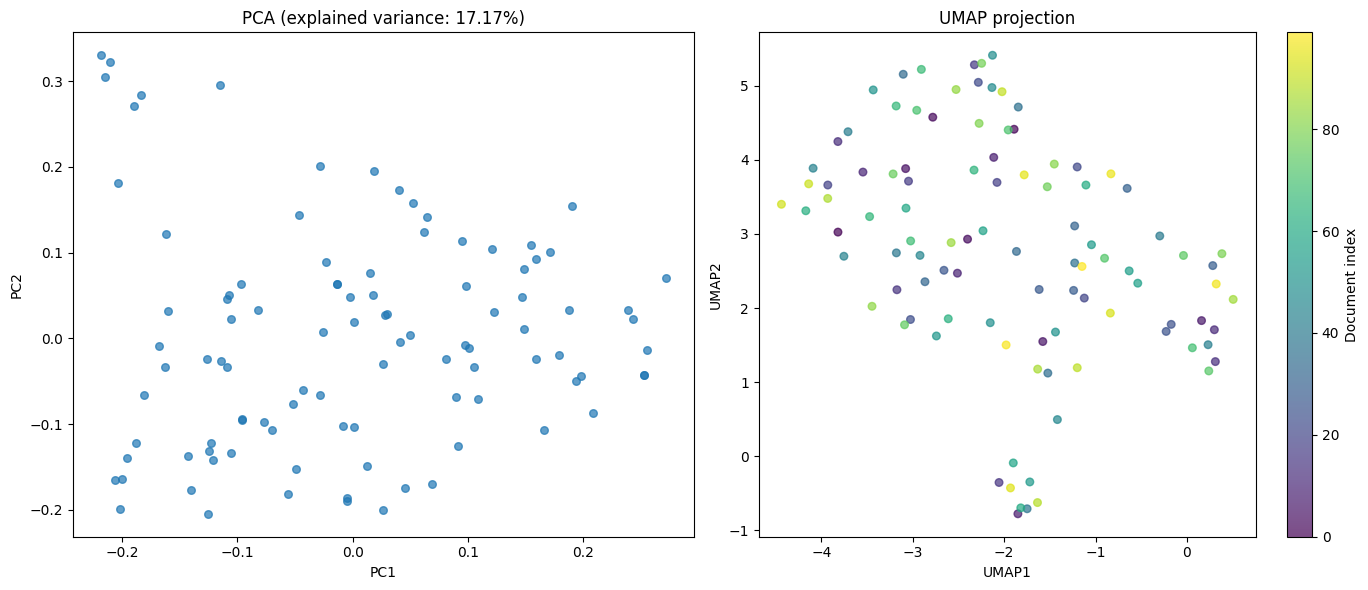

PCA explained variance ratio: [0.09064396 0.08104547]


In [11]:
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import numpy as np

embeddings_matrix = np.array([embeddings.embed_query(doc.page_content) for doc in documents])

pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings_matrix)

umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embeddings_umap = umap_reducer.fit_transform(embeddings_matrix)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], alpha=0.7, s=30)
axes[0].set_title(f'PCA (explained variance: {pca.explained_variance_ratio_.sum():.2%})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

scatter = axes[1].scatter(embeddings_umap[:, 0], embeddings_umap[:, 1],
                          c=range(len(documents)), cmap='viridis', alpha=0.7, s=30)
axes[1].set_title('UMAP projection')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')
plt.colorbar(scatter, ax=axes[1], label='Document index')

plt.tight_layout()
plt.show()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

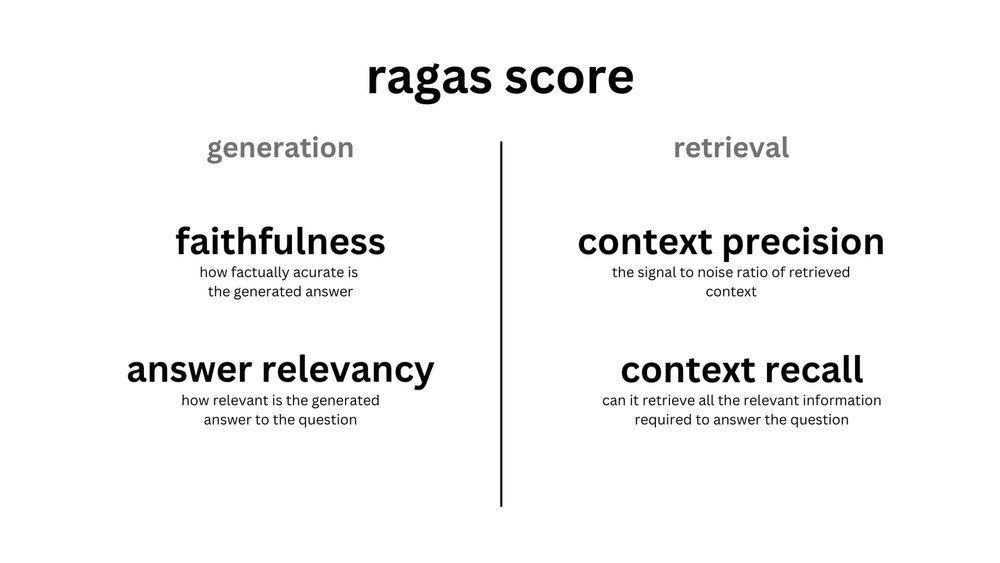

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [ ]:
def data_preprocess(samples_df, llm):

    dataset = []

    for idx, row in samples_df.iterrows():
        prompt = f"Придумай один короткий вопрос туриста об этой достопримечательности по описанию: {row['best_description'][:300]}"
        question = llm(prompt)  # need to implement llm call

        dataset.append({
            'question': question,
            'ground_truth': row['best_description'],
            'contexts': [row['best_description']]
        })

    return dataset

# HINT: для быстрого старта можно взять 20 сэмплов

In [12]:
def answer_relevancy(question: str, answer: str, embedder, n_questions: int = 3) -> float:
    # Генерируем искусственные вопросы
    gen_prompt = f"Сгенерируй {n_questions} разных вопросов, на которые отвечает данный текст: {answer}"
    generated_questions = [f"Что это за место?"] * n_questions  # TODO: заменить на LLM-генерацию

    # Эмбеддинги исходного вопроса
    q_emb = embedder.encode(question)

    # Эмбеддинги сгенерированных вопросов
    gen_embs = embedder.encode(generated_questions)

    # Косинусное сходство
    similarities = cosine_similarity([q_emb], gen_embs)[0]

    return float(np.mean(similarities))

# Протестируйте ваш RAG (3 балла)

In [13]:
import random
from sklearn.metrics.pairwise import cosine_similarity

def generate_answer(query, rag_results):
    context = "\n".join([res['content'][:200] for res in rag_results[:2]])
    return f"На основе найденных мест: {context[:200]}..."

test_queries = [
    "где находится старинная церковь?",
    "памятник архитектуры в центре города",
    "здание с часами и башней",
    "историческое место рядом с рекой",
    "достопримечательность с золотыми куполами"
]

scores = []
embedder = SentenceTransformer('intfloat/multilingual-e5-small')

for query in test_queries:
    results = rag_search(query, k=3)
    answer = generate_answer(query, results)

    q_emb = embedder.encode(query)
    a_emb = embedder.encode(answer)

    relevancy = cosine_similarity([q_emb], [a_emb])[0][0]
    scores.append(relevancy)

    print(f"Q: {query}")
    print(f"Top: {results[0]['metadata']['name']} ({results[0]['metadata']['city']})")
    print(f"Answer relevancy: {relevancy:.3f}\n")

print(f"Средняя Answer Relevancy: {np.mean(scores):.3f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Q: где находится старинная церковь?
Top: Николо-Тропинская церковь (Ярославль)
Answer relevancy: 0.824

Q: памятник архитектуры в центре города
Top: Динамо (Екатеринбург)
Answer relevancy: 0.840

Q: здание с часами и башней
Top: Здание бывшей гостиницы "Мадрид" (Екатеринбург)
Answer relevancy: 0.852

Q: историческое место рядом с рекой
Top: Храм Архангела Михаила (Ярославль)
Answer relevancy: 0.835

Q: достопримечательность с золотыми куполами
Top: Дом Степанова (Екатеринбург)
Answer relevancy: 0.825

Средняя Answer Relevancy: 0.835


# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [18]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

embedder = SentenceTransformer('intfloat/multilingual-e5-small')

def context_relevancy_embedding(query: str, contexts: list, embedder, threshold: float = 0.5) -> float:
    q_emb = embedder.encode([query])

    ctx_embs = embedder.encode(contexts)

    similarities = cosine_similarity(q_emb, ctx_embs)[0]

    relevant = (similarities >= threshold).astype(int)

    if relevant.sum() == 0:
        return 0.0

    precision_sum = 0
    relevant_seen = 0
    for i, rel in enumerate(relevant):
        if rel:
            relevant_seen += 1
            precision_sum += relevant_seen / (i + 1)

    return precision_sum / relevant.sum()

test_queries = [
    "церковь с золотыми куполами",
    "спортивный комплекс",
    "памятник архитектуры",
    "здание с часами на башне"
]

for query in test_queries:
    results = rag_search(query, k=5)
    contexts = [r['content'] for r in results]

    score = context_relevancy_embedding(query, contexts, embedder, threshold=0.4)
    print(f"Q: {query}")
    print(f"Context Relevancy: {score:.3f}")
    print(f"Top контекст: {contexts[0][:100]}...\n")

print("Метрика показывает, насколько первые результаты релевантны запросу семантически.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Q: церковь с золотыми куполами
Context Relevancy: 1.000
Top контекст: an old photo of a church with a clock tower and a clock tower...

Q: спортивный комплекс
Context Relevancy: 1.000
Top контекст: an old photo of a large building with a clock on top...

Q: памятник архитектуры
Context Relevancy: 1.000
Top контекст: an old photo of a church with a clock tower and a clock tower...

Q: здание с часами на башне
Context Relevancy: 1.000
Top контекст: there is a building with a clock on the top of it...

Метрика показывает, насколько первые результаты релевантны запросу семантически.
